# Email Phishing Detection (Colab)
Train and evaluate an email phishing classifier.

Label mapping: `1 = phishing`, `0 = legitimate`.

In [1]:
# Optional in Colab
# !pip -q install tensorflow scikit-learn pandas matplotlib seaborn

import pickle
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Attention, GlobalAveragePooling1D, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print('TensorFlow:', tf.__version__)

TensorFlow: 2.21.0


In [2]:
# Colab upload (run in Colab only)
# from google.colab import files
# files.upload()

from pathlib import Path

email_files = [Path('../email 1.csv'), Path('../email 2.csv'), Path('../email 3.csv')]
if not all(p.exists() for p in email_files):
    email_files = [Path('../../email 1.csv'), Path('../../email 2.csv'), Path('../../email 3.csv')]

df = pd.concat([pd.read_csv(f) for f in email_files], ignore_index=True)
df['subject'] = df['subject'].fillna('')
df['body'] = df['body'].fillna('')
df['text'] = df['subject'] + ' ' + df['body']
y = pd.to_numeric(df['label'], errors='coerce').fillna(0).astype(int).values

def clean_text(t):
    t = str(t).lower()
    t = re.sub(r'[^a-z0-9\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

texts = df['text'].map(clean_text).tolist()
X_train_txt, X_test_txt, y_train, y_test = train_test_split(texts, y, test_size=0.2, random_state=42, stratify=y)
print(f'Total rows: {len(df)} | Train rows: {len(X_train_txt)} | Test rows: {len(X_test_txt)}')

max_words, max_len = 12000, 120
tok = Tokenizer(num_words=max_words, oov_token='<oov>')
tok.fit_on_texts(X_train_txt)
X_train = pad_sequences(tok.texts_to_sequences(X_train_txt), maxlen=max_len, padding='post', truncating='post')
X_test = pad_sequences(tok.texts_to_sequences(X_test_txt), maxlen=max_len, padding='post', truncating='post')

vocab_size = min(max_words, len(tok.word_index) + 1)
inp = Input(shape=(max_len,))
x = Embedding(vocab_size, 128)(inp)
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Attention()([x, x])
x = GlobalAveragePooling1D()(x)
x = Dense(64, activation='relu')(x)
out = Dense(1, activation='sigmoid')(x)
model = Model(inp, out)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Total rows: 48295 | Train rows: 38636 | Test rows: 9659


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 120)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 120, 128)  │  1,536,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 120, 128)  │     98,816 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 120, 128)  │          0 │ bidirectional[0]… │
│ (Attention)         │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,643,137 (6.27 MB)

 Trainable params: 1,643,137 (6.27 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
544/544 ━━━━━━━━━━━━━━━━━━━━ 87s 148ms/step - accuracy: 0.9605 - loss: 0.1048 - val_accuracy: 0.9899 - val_loss: 0.0322
Epoch 2/4
544/544 ━━━━━━━━━━━━━━━━━━━━ 79s 145ms/step - accuracy: 0.9937 - loss: 0.0213 - val_accuracy: 0.9915 - val_loss: 0.0278
Epoch 3/4
544/544 ━━━━━━━━━━━━━━━━━━━━ 80s 147ms/step - accuracy: 0.9974 - loss: 0.0093 - val_accuracy: 0.9925 - val_loss: 0.0365
Epoch 4/4
544/544 ━━━━━━━━━━━━━━━━━━━━ 127s 234ms/step - accuracy: 0.9986 - loss: 0.0052 - val_accuracy: 0.9912 - val_loss: 0.0449


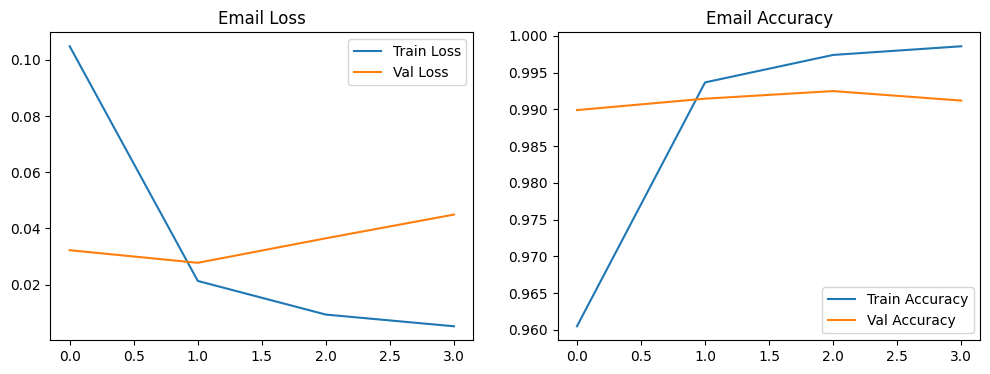

Final Train Accuracy: 0.9986
Final Val Accuracy: 0.9912


In [3]:
hist = model.fit(X_train, y_train, validation_split=0.1, epochs=4, batch_size=64, verbose=1)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(hist.history['loss'], label='Train Loss')
plt.plot(hist.history['val_loss'], label='Val Loss')
plt.title('Email Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist.history['accuracy'], label='Train Accuracy')
plt.plot(hist.history['val_accuracy'], label='Val Accuracy')
plt.title('Email Accuracy')
plt.legend()
plt.show()

print('Final Train Accuracy:', round(hist.history['accuracy'][-1], 4))
print('Final Val Accuracy:', round(hist.history['val_accuracy'][-1], 4))

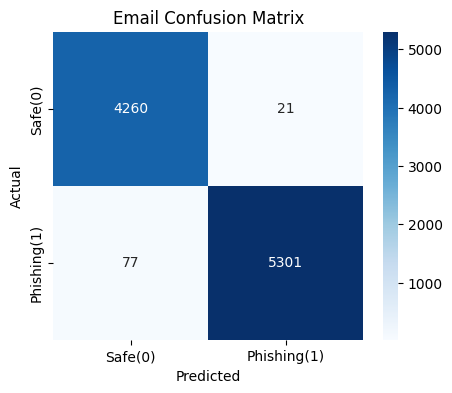

Accuracy : 0.9899
Precision: 0.9961
Recall   : 0.9857
F1-score : 0.9908
Saved: ../backend/models/email_model.h5
Saved: ../backend/tokenizer/email_tokenizer.pkl


In [4]:
proba = model.predict(X_test, verbose=0).ravel()
pred = (proba >= 0.5).astype(int)

cm = confusion_matrix(y_test, pred, labels=[0,1])
acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred, zero_division=0)
rec = recall_score(y_test, pred, zero_division=0)
f1 = f1_score(y_test, pred, zero_division=0)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Safe(0)','Phishing(1)'], yticklabels=['Safe(0)','Phishing(1)'])
plt.title('Email Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print('Accuracy :', round(acc, 4))
print('Precision:', round(prec, 4))
print('Recall   :', round(rec, 4))
print('F1-score :', round(f1, 4))

from pathlib import Path
artifact_root = Path('../backend')
(artifact_root / 'models').mkdir(parents=True, exist_ok=True)
(artifact_root / 'tokenizer').mkdir(parents=True, exist_ok=True)

model.save(artifact_root / 'models' / 'email_model.h5')
with open(artifact_root / 'tokenizer' / 'email_tokenizer.pkl', 'wb') as f:
    pickle.dump(tok, f)

print('Saved: ../backend/models/email_model.h5')
print('Saved: ../backend/tokenizer/email_tokenizer.pkl')